In [ ]:
using Pkg
Pkg.activate("/home/chrisstrong/MRI_Driving/inverse-feedback-games/")
using iLQGames
import iLQGames: dx
using Plots
using ForwardDiff
using iLQGames:
    SystemTrajectory
using iLQGames:
    LinearSystem
using Infiltrator
using Optim
using LinearAlgebra
using Distributed
using Dates
using Statistics


include("../src/diff_solver.jl")
include("../src/experiment_utils.jl") # NOTICE!! Many functions are defined there.

In [2]:
# added imports by Chris 
import Base.length
using BenchmarkTools
using LazySets
using LinearAlgebra
using Plots
using PyCall
using Random 

### Geometric utilities

In [3]:
# Abstract TrajectoryPlan type which 
# we want to be able to get distance from and distance along 
abstract type TrajectoryPlan end

"""
    Arc setup and Arc specific functions
"""
# These are directional with respect to calculating progress 
struct Arc <: TrajectoryPlan
    center
    radius
    start_angle
    end_angle
    clockwise::Bool

    function Arc(center, radius, start_angle, end_angle, clockwise::Bool=false)
        # Make sure the angles are between 0 and 2pi
        start_angle = mod(start_angle, 2*pi)
        end_angle = mod(end_angle, 2*pi)
    
        return new(center, radius, start_angle, end_angle, clockwise)
    end
end

function ordered_start_end_angle(start_angle, end_angle, clockwise)
# Makes the angles in the range [0, 4*pi) and orders them so that if you did a linspace 
# from start_angle to end_angle, you would get the arc.

# if you're going clockwise then start angle will be larger than end angle 
# if you're going counter clockwise then start angle will be smaller than end angle 
    if clockwise
        if start_angle < end_angle
            start_angle += 2 * pi
        end
    else
        if end_angle < start_angle
            end_angle += 2 * pi
        end
    end
    return start_angle, end_angle
end

function is_angle_between(angle, start_angle, end_angle, clockwise)
    # all angles must be between [0, 2pi)
    if clockwise
        if start_angle >= end_angle
            return start_angle >= angle >= end_angle
        else
            return angle <= start_angle || angle >= end_angle
        end
    else
        if start_angle <= end_angle
            return start_angle <= angle <= end_angle
        else
            return angle >= start_angle || angle <= end_angle
        end
    end
end


function sampled_projection(point, arc::Arc; num_samples::Int=1000)
    start_angle, end_angle = ordered_start_end_angle(arc.start_angle, arc.end_angle, arc.clockwise)
    angles = LinRange(arc.start_angle, arc.end_angle, num_samples)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    # project the point onto the arc
    distances = [norm(point - p) for p in points]
    min_distance, min_index = findmin(distances)

    return points[min_index]
end

function segment_length(arc::Arc)
    start_angle, end_angle = ordered_start_end_angle(arc.start_angle, arc.end_angle, arc.clockwise)
    return arc.radius * abs(end_angle - start_angle)
end

function contains(arc::Arc, point)
    angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    return is_angle_between(angle, arc.start_angle, arc.end_angle, arc.clockwise)
end

function project(point, arc::Arc)
    # find the angle of the point with respect to the center of the arc
    angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    start_angle, end_angle = arc.start_angle, arc.end_angle

    # now, check if the angle is within the arc. if it is, then the projected point 
    # is in the interior of the arc. otherwise, it's one of the edge points. 
    if is_angle_between(angle, start_angle, end_angle, arc.clockwise)
        projected_point = arc.center .+ arc.radius * [cos(angle), sin(angle)]
    else
        start_vertex = arc.center .+ arc.radius * [cos(start_angle), sin(start_angle)]
        end_vertex = arc.center .+ arc.radius * [cos(end_angle), sin(end_angle)]
        distance_start_vertex = norm(point - start_vertex)
        distance_end_vertex = norm(point - end_vertex)
        if distance_start_vertex < distance_end_vertex
            projected_point = start_vertex
        else
            projected_point = end_vertex
        end
    end 

    return projected_point
end 

function progress(point, arc::Arc)
    # Point should be on the arc TODO: assert that  
    angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    if arc.clockwise 
        if angle > arc.start_angle 
            # then it will go all the way down to 0, then jump to 2pi and continue down until it hits it 
            angle_change = arc.start_angle + (2*pi - angle)
        else 
            angle_change = arc.start_angle - angle
        end
    else 
        if angle < arc.start_angle 
            # then it will go all the way up to 2pi, jump to 0, then continue until it hits it 
            angle_change = 2*pi - arc.start_angle + angle
        else
            angle_change = angle - arc.start_angle
        end
    end
    return angle_change * arc.radius

    # angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    # return mod(angle - arc.start_angle, 2*pi) * arc.radius
end

function point_from_progress(progress, arc::Arc)
    angle_change = progress / arc.radius
    angle = arc.start_angle + sign(arc.end_angle - arc.start_angle) * angle_change
    return arc.center + arc.radius .* [cos(angle), sin(angle)]
end

function visualize(arc::Arc; kwargs...)
    angles = LinRange(arc.start_angle, arc.end_angle, 100)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    return plot!([p[1] for p in points], [p[2] for p in points]; label="", kwargs...)
end

"""
    Line segment specific functions
"""

function segment_length(line::LineSegment)
    return norm(line.q - line.p)
end

function contains(line::LineSegment, point)
    # Check if the point is on the line segment 
    return norm(point - line.p) + norm(point - line.q) ≈ segment_length(line)
end

function project(point, line::LineSegment)
    # Project the point onto the line segment 
    v = line.q - line.p
    w = point - line.p
    c = dot(w, v) / dot(v, v)

    # if c is less than 0, then the closest point is the start point
    if c <= 0
        return line.p
    end

    # if c is greater than 1, then the closest point is the end point
    if c >= 1
        return line.q
    end

    return line.p + c * v
end

function progress(point, line::LineSegment)
    # Point should be on the line segment TODO: assert that 
    return norm(point - line.p) # distance from the start point 
end

function visualize(l::LineSegment; kwargs...)
    return plot!(l; label="", kwargs...)
end

"""
    Trajectory plan that contains several subtrajectories 
"""
struct ListTrajectoryPlan <: TrajectoryPlan
    subtrajectories
end

function segment_length(trajectory::ListTrajectoryPlan)
    return sum([segment_length(subtrajectory) for subtrajectory in trajectory.subtrajectories])
end

function contains(trajectory::ListTrajectoryPlan, point)
    for subtrajectory in trajectory.subtrajectories
        if contains(subtrajectory, point)
            return true
        end
    end
    return false
end

function project(point, trajectory::ListTrajectoryPlan)
    # Project the point onto each subtrajectory and return the closest one 
    projected_points = [project(point, subtrajectory) for subtrajectory in trajectory.subtrajectories]
    distances = [norm(point - projected_point) for projected_point in projected_points]
    min_distance, min_index = findmin(distances)

    return projected_points[min_index]
end

function progress(point, trajectory::ListTrajectoryPlan)
    accumulated_progress = 0
    for subtrajectory in trajectory.subtrajectories
        if contains(subtrajectory, point)
            return accumulated_progress + progress(point, subtrajectory)
        else
            accumulated_progress += segment_length(subtrajectory)
        end 
    end
end

function visualize(trajectory::ListTrajectoryPlan; kwargs...)
    for subtrajectory in trajectory.subtrajectories
        visualize(subtrajectory; kwargs...)
    end
    return plot!()
end

"""
    Generic functions for any of our types of sets
"""
# For this to work for a set, need project(point, set) and progress(point, set) to be defined.
function project_frenet_coordinates(point, set)
    projected_point = project(point, set)

    # Distance along curve is the first new coordinate (the progress)
    distance_along_curve = progress(projected_point, set)

    # Distance from the curve is the second new coordinate 
    distance_from_curve = norm(point - projected_point)

    return distance_along_curve, distance_from_curve, projected_point 
end

function distance_and_projection(point, set)
    projected_point = project(point, set)
    distance = norm(point - projected_point)
    return distance, projected_point
end 


distance_and_projection (generic function with 1 method)

#### Testing the geometric utilities

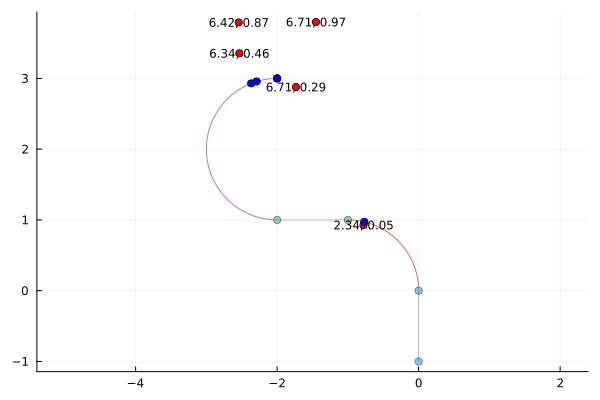

In [4]:
plot()
line_segment_1 = LineSegment([0., -1], [0., 0])
curve_1 = Arc([-1., 0], 1., 0., pi/2, false)
line_segment_2 = LineSegment([-1., 1], [-2., 1])
# turn right 
curve_2 = Arc([-2., 2], 1., 3*pi/2, pi/2, true)
trajectory = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2, curve_2])
visualize(trajectory)

# equal axis scale
plot!(aspect_ratio=:equal)


# benchmark time to project 1000 points onto the trajectory
points = [5 * rand(2) .- 1 for _ in 1:1000]
#@btime project(point, trajectory) setup=(point=3*rand(2) .- 1)

# generate random points, project onto trajectory 
num_points = 5
points = [[3 * rand(), 5 * rand()] - [3, 1] for _ in 1:num_points]

# for each point get its frenet coordinates and the point 
frenet_results = [project_frenet_coordinates(point, trajectory) for point in points]
distances_along_curve, distances_from_curve, projected_points = zip(frenet_results...)

for (point, distance_along_curve, distance_from_curve) in zip(points, distances_along_curve, distances_from_curve)
    scatter!([point[1]], [point[2]], color="red")
    # label each with distance along curve and distance from curve after rounding to 2 digits
    label = "$(round(distance_along_curve, digits=2)), $(round(distance_from_curve, digits=2))"
    annotate!([point[1]], [point[2]], text(label, 8, :black))
end

for point in projected_points
    scatter!([point[1]], [point[2]], color="blue")
end
# remove legend
plot!(legend=false)


### Testing the Solver

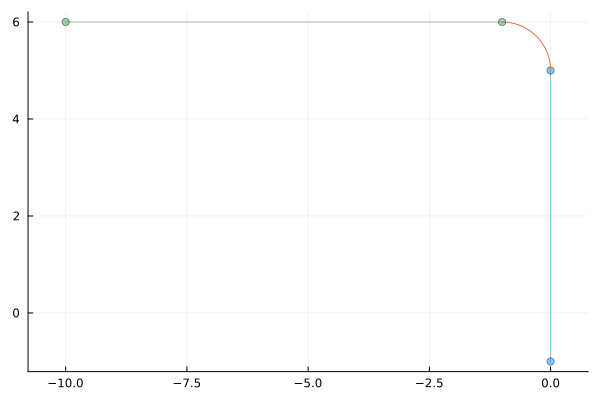

In [5]:
# trajectory to try to get it to track 
plot()
line_segment_1 = LineSegment([0., -1], [0., 5])
curve_1 = Arc([-1., 5], 1., 0., pi/2, false)
line_segment_2 = LineSegment([-1., 6], [-10., 6])
# turn right 
curve_2 = Arc([-2., 2], 1., 3*pi/2, pi/2, true)
# trajectory = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2, curve_2])
trajectory_plan = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2])

visualize(trajectory_plan)
plot!(aspect_ratio=:equal)

#### Two Players

In [6]:
function relu(x)
    return max.(0, x)
end

relu (generic function with 1 method)

In [7]:
# parametes: number of states, number of inputs, sampling time, horizon
nx, nu, ΔT, game_horizon = 9, 4, 0.1, 40
struct DoubleUnicycle <: ControlSystem{ΔT,nx,nu} end

# setup the dynamics
# state: (px, py, phi, v)
dx(cs::DoubleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2], 
                                    x[8]cos(x[7]), x[8]sin(x[7]), u[3], u[4],0)
dynamics = DoubleUnicycle()

# some parameters for the cost function 
ego_v_desired = 1.5
other_v_desired = 1.0
ego_comfortable_distance = 0.5

ego_weight_distance_along_curve = 1.0
ego_weight_distance_from_curve = 60.0
ego_weight_velocity = 5.0
ego_weight_control = 1.0
ego_weight_distance = 100.0

other_weight_distance_along_curve = 1.0
other_weight_distance_from_curve = 30.0
other_weight_velocity = 10.0
other_weight_control = 1.0



function distance_within_arc(point, arc)
    #arc = Arc([-9., 0.], 10., 0., pi/2, false)
    # assume we're inside the arc 

    angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    if arc.start_angle <= angle <= arc.end_angle
        return arc.radius - norm(point - arc.center)
    else 
        # find the two endpoints of the arc, return the minimum distance to them 
        start_vertex = arc.center .+ arc.radius * [cos(arc.start_angle), sin(arc.start_angle)]
        end_vertex = arc.center .+ arc.radius * [cos(arc.end_angle), sin(arc.end_angle)]
        distance_start_vertex = norm(point - start_vertex)
        distance_end_vertex = norm(point - end_vertex)
        return min(distance_start_vertex, distance_end_vertex)
    end
end

function wrapper_fcn(point)
    dist_along_curve, dist_from_curve, _ = project_frenet_coordinates(point, trajectory_plan)
    return [dist_along_curve, dist_from_curve]
end 

# Define the cost functions for each player 
function ego_vehicle_cost(g, x, u, t)
    # cost for ego vehicle
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    other_x, other_y, other_phi, other_v = x[5:8]
    desired_x = x[9]
    ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

    distance_between_vehicles = norm([ego_x, ego_y] - [other_x, other_y])
    distance_penalty = relu(ego_comfortable_distance - distance_between_vehicles)^2

    return -ego_weight_distance_along_curve * ego_distance_along_curve + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control * (u[1]^2 + u[2]^2) + ego_weight_distance*distance_penalty
end
    
function other_vehicle_cost(g, x, u, t)
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    other_x, other_y, other_phi, other_v = x[5:8]
    desired_x = x[9]
    other_distance_along_curve, other_distance_from_curve = wrapper_fcn([other_x, other_y])

    #return 10 * (other_v - 1)^2 + 100 * (u[3]^2 + u[4]^2)
    return -other_weight_distance_along_curve * other_distance_along_curve + other_weight_distance_from_curve * other_distance_from_curve^2 + other_weight_velocity * (other_v - other_v_desired)^2 + other_weight_control * (u[3]^2 + u[4]^2)
end

function parameterized_cost(theta)
end


costs = (FunctionPlayerCost(ego_vehicle_cost), FunctionPlayerCost(other_vehicle_cost))

# indices of inputs that each player controls
player_inputs = (SVector(1,2), SVector(3,4))
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)

# get a solver, choose initial conditions and solve (in about 9 ms with AD)
ego_x_0 = 0.5

x0 = SVector(0.0, 2.5, pi/2, 1,       0.0, 4, pi/2, 1,         0.2)

# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: You are using the fallback linearization using ForwardDiff. Consider
│     implementing a custom `linearize` or `linearize_discrete` for your
│     `ControlSystem` type.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/control_system.jl:122
┌ Warning: You are using the fallback quadraticization using ForwardDiff.
│     Consider implementing a custom `quadraticize` for your `ControlSystem`
│     type.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/quadraticize.jl:8


(true, SystemTrajectory{40, 0.1, 9, 4, SizedVector{40, SVector{9, Float64}, Vector{SVector{9, Float64}}}, SizedVector{40, SVector{4, Float64}, Vector{SVector{4, Float64}}}}(SVector{9, Float64}[[0.0, 2.5, 1.5707963267948966, 1.0, 0.0, 4.0, 1.5707963267948966, 1.0, 0.2], [-3.921151502609326e-5, 2.606338951438595, 1.5715194399799244, 1.1267792196424362, 0.0006173334745740037, 4.102610483891576, 1.5588651828419589, 1.0522589880055144, 0.2], [-0.00011637084757496095, 2.723983204647499, 1.5713868195489051, 1.2261063523237472, 0.0021298549642689607, 4.209649449782353, 1.5544930434040802, 1.0887357521359182, 0.2], [-0.0001228197955526135, 2.8504609411478086, 1.5703186977241148, 1.303448501180268, 0.0037364775949585705, 4.319751432601857, 1.5579046101180838, 1.1135394002122188, 0.2], [8.02544139831172e-5, 2.9837919024775466, 1.5682432855977537, 1.363174296907729, 0.004532124959564711, 4.4319083645895265, 1.5694724483632285, 1.1296681895230036, 0.2], [0.0006524637223223623, 3.122387997226124, 1.

┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/example_turning_vs=[1.5, 1.0]_comfortabledist=0.5.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/example_turning_vs=[1.5, 1.0]_comfortabledist=0.5.gif")
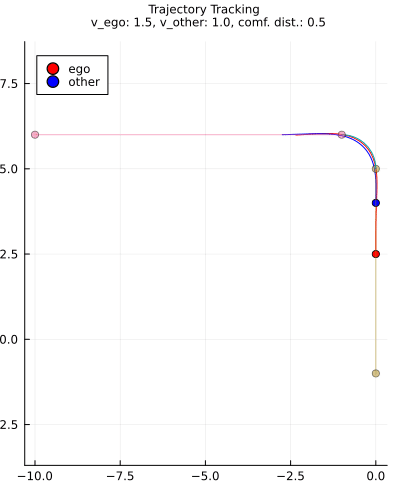

In [8]:
# Visualize the results 
agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]
agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]

agent2_x = [expert_traj.x[t][5] for t in 1:game_horizon]
agent2_y = [expert_traj.x[t][6] for t in 1:game_horizon]

anim=@animate for t in 1:game_horizon
    plot(agent1_x, agent1_y, color="red", label="")
    plot!(agent2_x, agent2_y, color="blue", label="")
    scatter!([agent1_x[t]], [agent1_y[t]], label="ego", legend=:topleft, color="red")
    scatter!([agent2_x[t]], [agent2_y[t]], label="other", legend=:topleft, color="blue")
    plot!(size=(400,500))
    plot!(aspect_ratio=:equal, legend=:topleft)
    visualize(trajectory_plan)
    plot!(title="Trajectory Tracking \n v_ego: $ego_v_desired, v_other: $other_v_desired, comf. dist.: $ego_comfortable_distance", titlefontsize=8)
end
save_file = string("visualizations/example_turning_vs=[",  ego_v_desired, ", ", other_v_desired, "]_comfortabledist=", ego_comfortable_distance, ".gif")
gif(anim, save_file, fps = 5)


In [9]:
# # Define the cost functions for each player 
# function ego_vehicle_cost(g, x, u, t, theta)
#     # cost for ego vehicle
#     ego_x, ego_y, ego_phi, ego_v = x[1:4]
#     other_x, other_y, other_phi, other_v = x[5:8]
#     desired_x = x[9]
#     ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

#     distance_between_vehicles = norm([ego_x, ego_y] - [other_x, other_y])
#     distance_penalty = relu(ego_comfortable_distance - distance_between_vehicles)^2

#     ego_weight_distance_along_curve = theta[1]
#     return -ego_weight_distance_along_curve * ego_distance_along_curve + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control * (u[1]^2 + u[2]^2) + ego_weight_distance*distance_penalty
# end
    
# function other_vehicle_cost(g, x, u, t, theta)
#     ego_x, ego_y, ego_phi, ego_v = x[1:4]
#     other_x, other_y, other_phi, other_v = x[5:8]
#     desired_x = x[9]
#     other_distance_along_curve, other_distance_from_curve = wrapper_fcn([other_x, other_y])

#     #return 10 * (other_v - 1)^2 + 100 * (u[3]^2 + u[4]^2)
#     return -other_weight_distance_along_curve * other_distance_along_curve + other_weight_distance_from_curve * other_distance_from_curve^2 + other_weight_velocity * (other_v - other_v_desired)^2 + other_weight_control * (u[3]^2 + u[4]^2)
# end

# function parameterized_cost(theta)
#     return (FunctionPlayerCost(g, x, u, t -> ego_vehicle_cost(g, x, u, t, theta)), FunctionPlayerCost(g, x, u, t -> other_vehicle_cost(g, x, u, t, theta)))
# end

### Single player

In [10]:
nx, nu, ΔT, game_horizon = 4, 2, 0.1, 40

# setup the dynamics
struct SingleUnicycle <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::SingleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2] )
dynamics = SingleUnicycle()

other_vehicle_prediction = [] # TODO: fill in prediction here 

function ego_vehicle_cost(g, x, u, t)
    # cost for ego vehicle
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

    # get index of this time step 
    # round t / delta T to an int 
    t_index = round(Int, t / ΔT)


    return -ego_weight_distance_along_curve * ego_distance_along_curve + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control * (u[1]^2 + u[2]^2)
end

costs = (FunctionPlayerCost(ego_vehicle_cost),)
#costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[1]-0)^2  +  2*(u[1]^2 + u[2]^2) )), ) # NOTE: the cost is a tuple of costs for each player

# indices of inputs that each player controls
player_inputs = (SVector(1,2),) # NOTE: the input is a tuple of inputs for each player
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)

# get a solver, choose initial conditions and solve (in about 9 ms with AD)
x0 = SVector(0, 3.0, pi/2, 1)


# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


(true, SystemTrajectory{40, 0.1, 4, 2, SizedVector{40, SVector{4, Float64}, Vector{SVector{4, Float64}}}, SizedVector{40, SVector{2, Float64}, Vector{SVector{2, Float64}}}}(SVector{4, Float64}[[0.0, 3.0, 1.5707963267948966, 1.0], [0.0004069300823171119, 3.1088213081480824, 1.5635142811621816, 1.176446178125885], [0.0017519948698383062, 3.2334014643307927, 1.556613830753617, 1.3153071035493253], [0.004146371357335313, 3.3703463192237915, 1.550100072075474, 1.4240134410514158], [0.00761875191645174, 3.516930007154809, 1.5441808287272258, 1.508487044811575], [0.012089902530869764, 3.670960941709405, 1.5394064300207115, 1.5734321681020687], [0.017313680433343265, 3.8306753854186555, 1.5368088753538225, 1.6225656880944626], [0.02278887685183862, 3.994652326716157, 1.5380240289205749, 1.658801000666664], [0.027650739131588963, 4.1617413492608195, 1.5453714123816247, 1.684401348051603], [0.030557003082093612, 4.33099058013804, 1.5618544730794617, 1.701120607213356]  …  [-2.320624502517141, 6.

┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/example_singleagent_turning.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/example_singleagent_turning.gif")
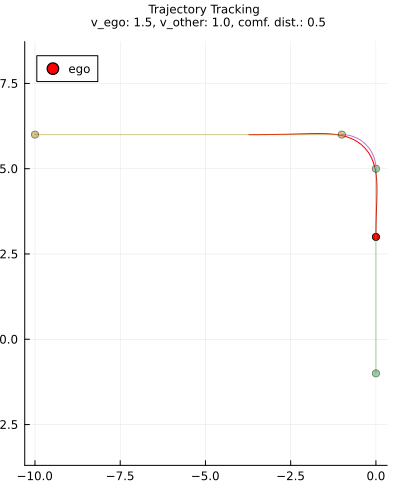

In [11]:
# visualize the results 
agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]

agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]

anim=@animate for t in 1:game_horizon
    plot(agent1_x, agent1_y, color="red", label="")
    scatter!([agent1_x[t]], [agent1_y[t]], label="ego", legend=:topleft, color="red")
    plot!(size=(400,500))
    plot!(aspect_ratio=:equal, legend=:topleft)
    visualize(trajectory_plan)
    plot!(title="Trajectory Tracking \n v_ego: $ego_v_desired, v_other: $other_v_desired, comf. dist.: $ego_comfortable_distance", titlefontsize=8)
end
save_file = string("visualizations/example_singleagent_turning.gif")
gif(anim, save_file, fps = 5)

### Data processing utils

In [5]:
function vehicle_index_to_col(index)
    return 6 + 5*(index - 1)
end

function pedestrian_index_to_col(index, k_closest_vehicles)
    return 6 + 5*k_closest_vehicles + 5*(index - 1)
end

function centerline_col(k_closest_vehicles, k_closest_pedestrians)
    return 6 + 5*k_closest_vehicles + 5*k_closest_pedestrians
end

k_closest_vehicles = 15
k_closest_pedestrians = 0

0

### Visualization Utils

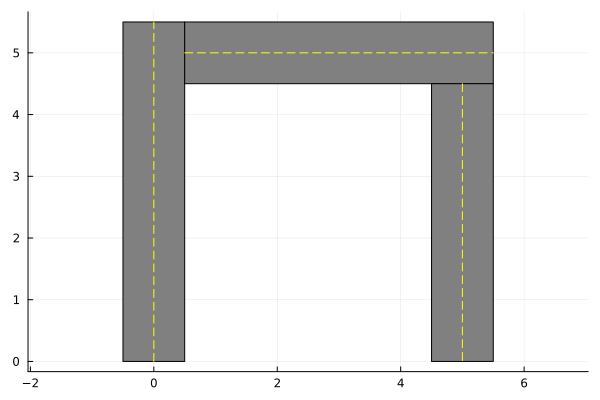

In [6]:
function visualize_road_segment(line_segment, road_width; color="gray", kwargs...)
    p, q = line_segment.p, line_segment.q
    v = p - q
    v = v / norm(v)

    perp = [0 -1; 1 0] * v
    rectangle_p1 = p + road_width / 2 * perp
    rectangle_p2 = p - road_width / 2 * perp
    rectangle_p3 = q - road_width / 2 * perp
    rectangle_p4 = q + road_width / 2 * perp
    plot!(polygon_from_points([rectangle_p1, rectangle_p2, rectangle_p3, rectangle_p4]); color=color, label="", kwargs...)
    
    # plot a yellow dashed line along the center and white lines along the edges 
    return plot!([p[1], q[1]], [p[2], q[2]], color="yellow", linestyle=:dash, label="")
end

function visualize_map(centerlines, road_width=1200; kwargs...)
    for centerline in centerlines
        visualize_road_segment(centerline, road_width; kwargs...)
    end
    return plot!()
end

rectangle(w, h, x, y) = Shape(x + [0,w,w,0], y + [0,0,h,h])
polygon_from_points(points) = Shape([p[1] for p in points], [p[2] for p in points])

function visualize_road_from_key_points(key_points, road_width; kwargs...)
    # between each key point draw a rectangle of width road_width 
    for i in 1:length(key_points) - 1
        p1 = key_points[i]
        p2 = key_points[i + 1]

        v = p2 - p1
        v = v / norm(v)

        # extend line to be road_width / 2 longer 
        # except for the first and last lines
        if i > 1
            p1 = p1 + road_width / 2 * v
        end
        if i < length(key_points) - 1
            p2 = p2 + road_width / 2 * v
        end

        visualize_road_segment(LineSegment(p1, p2), road_width; kwargs...)
    end
    return plot!(aspect_ratio=:equal)
end

plot()
visualize_road_from_key_points([[0., 0], [0., 5], [5., 5], [5., 0]], 1.0, color="gray")

In [7]:
# load labels
py"""
import numpy as np 
x = (np.load('/home/shared/fmri/full_dataset/SP/generated/demonstrations/train_ids_k_closest_vehicles=15_k_closest_pedestrians=0.npy'))
"""

y = py"x"
#train_ids = py"np.load('/home/shared/fmri/full_dataset/SP/generated/demonstrations/train_ids_k_closest_vehicles=15_k_closest_pedestrians=0.npy')"

PyObject array(['1_SP_20210126_13-52-24', '2_SP_20210126_14-08-22',
       '3_SP_20210126_14-23-30', '4_SP_20210126_14-38-49',
       '5_SP_20210126_14-53-46', '7_SP_20210218_12-22-16',
       '8_SP_20210218_12-37-33', '9_SP_20210218_12-53-04',
       '10_SP_20210218_13-08-22', '11_SP_20210218_13-23-23',
       '13_SP_20210322_09-41-29', '14_SP_20210322_09-56-51',
       '15_SP_20210322_10-14-12', '16_SP_20210322_10-29-30',
       '17_SP_20210322_10-45-03'], dtype='<U23')

### Loading actual data

Load the trajectories

In [14]:
py"""
import pickle
 
def load_pickle(fpath):
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    return data
"""

load_pickle = py"load_pickle"

train_demonstrations_turns = load_pickle("/home/shared/fmri/full_dataset/SP/generated/demonstrations/train_demonstrations_turns_k_closest_vehicles=15_k_closest_pedestrians=0.pkl")
train_point_sequences = load_pickle("/home/shared/fmri/full_dataset/SP/generated/demonstrations/train_point_sequences.pkl")

# also load the ones that are just straights 
train_demonstrations = load_pickle("/home/shared/fmri/full_dataset/SP/generated/demonstrations/train_demonstrations_k_closest_vehicles=15_k_closest_pedestrians=0.pkl")

# Some key points to test our visualization functions
key_points = train_point_sequences[1]


3-element Vector{Vector{Float64}}:
 [72424.5, 54220.0]
 [42719.0, 54220.0]
 [42719.0, 10586.5]

Load centerlines

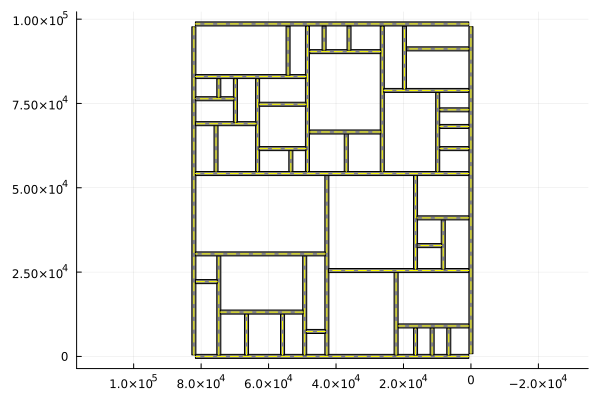

In [15]:
using NPZ
centerline_filename = "/home/shared/fmri/full_dataset/map_centerlines.npz"
centerlines = npzread(centerline_filename)["lines"]
centerlines = [LineSegment(centerlines[i, 1, :], centerlines[i, 2, :]) for i in 1:size(centerlines, 1)]

plot()
visualize_map(centerlines, 1200, color="gray")
plot!(aspect_ratio=:equal, xflip=true)

In [16]:
function road_shift_from_points(point1, point2, road_width)
    # Since we're using a left handed coordinate
    # if we're going in the positive x direction (left), the road shift is up in y 
    # if we're going in the negative x direction (right), the road shift is down in y 
    # if we're going in the positive y direction (up), the road shift is negative in x (right)
    # if we're going in the negative y direction (down), the road shift is positive in y (left)
    start_x, start_y, second_x, second_y = point1[1], point1[2], point2[1], point2[2]
    # assert x is constant or y is constant 
    @assert (start_x ≈ second_x || start_y ≈ second_y)

    if start_x < second_x
        road_shift = [0, road_width / 4]
    elseif start_x > second_x
        road_shift = [0, -road_width / 4]
    elseif start_y < second_y
        road_shift = [-road_width / 4, 0]
    elseif start_y > second_y
        road_shift = [road_width / 4, 0]
    end
    return road_shift
end

function shorten_segment(segment::LineSegment, dist_to_cut, direction="both")
    p, q = segment.p, segment.q
    v = q - p
    v = v / norm(v)
    if direction == "both"
        return LineSegment(p + v * dist_to_cut, q - v * dist_to_cut)
    elseif direction == "start"
        return LineSegment(p + v * dist_to_cut, q)
    elseif direction == "end"
        return LineSegment(p, q - v * dist_to_cut)
    else 
        error("Invalid direction")
    end
end 

function is_right_turn(direction_1, direction_2)
    # in left-handed coordinates, check to see if the turn is right. 
    # direction_1 should be the direction you start heading, and direction 2 should be the direction you end up heading 
    # if the cross product of the two vectors is positive, then it's a right turn
    return cross([direction_1; 0], [direction_2; 0])[3] > 0
end

function trajectory_plan_from_key_points(key_points, road_width = 900)
    # go along alternating between straights and arcs, is that always right? 
    # we'll note that we're in a left handed coordinate system, so left is more positive xs and right is 

    trajectory_segments = []
    
    # From the first two points get a line 
    point1, point2 = key_points[1], key_points[2]
    road_shift = road_shift_from_points(point1, point2, road_width)
    line_segment = LineSegment(point1 + road_shift, point2 + road_shift)
    # shorten the end of the line segment by 0.5*road_width 
    line_segment = shorten_segment(line_segment, 0.5*road_width, "end")
    push!(trajectory_segments, line_segment)

    # now for each trio we'll add a curve then a straight 
    for i = 1:(length(key_points) - 2)
        point1, point2, point3 = key_points[i], key_points[i+1], key_points[i+2]

        # get the vector from point1 to point2
        direction_1 = (point1 - point2) / norm(point1 - point2)
        # get the vector from point2 to point3
        direction_2 = (point3 - point2) / norm(point3 - point2)

        # add on the segment from point 2 to point 3 
        road_shift = road_shift_from_points(point2, point3, road_width)
        line_segment = LineSegment(point2 + road_shift, point3 + road_shift)
        # shorten line segment on both sides by 0.5*road_width unless we're on the last index
        # in which case we just shorten the start and not the end  
        if i == length(key_points) - 2
            line_segment = shorten_segment(line_segment, 0.5*road_width, "start")
        else 
            line_segment = shorten_segment(line_segment, 0.5*road_width, "both")
        end

        right_turn = is_right_turn(-direction_1, direction_2)
        center_shift_amount = right_turn ? road_width / 2 : road_width / 4
        circle_center = point2 + center_shift_amount * direction_1 + center_shift_amount * direction_2
        
        # now see the angle from the end of the previous line segment to this circle 
        previous_line_segment = trajectory_segments[end]
        previous_end = previous_line_segment.q
        start_angle = atan(previous_end[2] - circle_center[2], previous_end[1] - circle_center[1])
        
        # now see the angle from the start of the next line segment to this circle 
        next_line_segment = line_segment
        next_start = next_line_segment.p
        end_angle = atan(next_start[2] - circle_center[2], next_start[1] - circle_center[1])

        clockwise = ~right_turn 
        if clockwise 
            # right turn in left-handed frame is a left turn, so larger radius 
            circle_radius = 3 * road_width / 4
        else 
            circle_radius = road_width / 4
        end
        arc = Arc(circle_center, circle_radius, start_angle, end_angle, clockwise)
        
        push!(trajectory_segments, line_segment)
        push!(trajectory_segments, arc)
    end
    
    return ListTrajectoryPlan(trajectory_segments)
end 

road_width = 1200

plot()
# plot the trajectory and key points 
visualize_road_from_key_points(key_points, road_width)
plot!(xs, ys, color="red", label="")
#scatter!(key_xs, key_ys, color="blue", label="")

# now visualize the plan 
trajectory_plan = trajectory_plan_from_key_points(key_points, road_width)
visualize(trajectory_plan, color="blue")

# axis equal 
plot!(aspect_ratio=:equal, xflip=true)
# set x limits and y limits 
plot!(xlims=(40000, 60000), ylims=(45000, 55000))

UndefVarError: UndefVarError: `xs` not defined

In [17]:
# animate the trajectory on the trajectory plan 
width_around_car = 5000
height_around_car = 5000 

anim=@animate for t in 500:5:900
    visualize_road_from_key_points(key_points, road_width, color="gray")

    # plot with a single circle the current location 
    scatter!([xs[t]], [ys[t]], color="blue", label="")

    # plot the plan 
    visualize(trajectory_plan, color="blue")

    plot!(size=(400,500))
    plot!(aspect_ratio=:equal, legend=:topleft, xflip=true)
    # set x limits and y limits
    plot!(xlims=(xs[t] - width_around_car, xs[t] + width_around_car), ylims=(ys[t] - height_around_car, ys[t] + height_around_car))
end
gif(anim, "visualizations/trajectory_from_data.gif", fps = 10)

UndefVarError: UndefVarError: `xs` not defined

┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif")
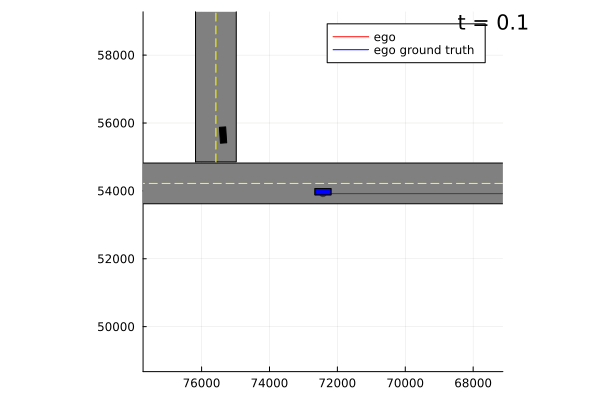

In [49]:
function plot_car_at_state(x, y, heading, velocity; width=185, height=470, color="black", kwargs...)
    # plot a rectangle at x, y, with given heading 

    front_right = [x + height / 2 * cos(heading) + width / 2 * cos(pi/2 - heading), y + height / 2 * sin(heading) - width / 2 * sin(pi/2 - heading)]
    front_left = [x + height / 2 * cos(heading) - width / 2 * cos(pi/2 - heading), y + height / 2 * sin(heading) + width / 2 * sin(pi/2 - heading)]
    back_left = [x - height / 2 * cos(heading) - width / 2 * cos(pi/2 - heading), y - height / 2 * sin(heading) + width / 2 * sin(pi/2 - heading)]
    back_right = [x - height / 2 * cos(heading) + width / 2 * cos(pi/2 - heading), y - height / 2 * sin(heading) - width / 2 * sin(pi/2 - heading)]
    
    # plot rectangle 
    plot!(polygon_from_points([front_right, front_left, back_left, back_right]), color=color, label="", kwargs...)
    # plot arrow from center in direction of heading 
    arrow_length = height*1.5
    arrow_delta_x = arrow_length * cos(heading)
    arrow_delta_y = arrow_length * sin(heading)
    #return quiver!([x], [y], quiver=([arrow_delta_x], [arrow_delta_y]), color=color, label="", kwargs...)
    #return plot!([x + arrow_delta_x, x], [y + arrow_delta_y, y], color=color, arrow=false, label="", kwargs...)
    return plot!()
end

function animate_trajectories(trajectories, colors, labels, demonstration, trajectory_plan, road_width; time_spacing=5, field_of_view=5000, k_closest_vehicles=15, kwargs...)
    """
    trajectories: list of trajectories, each of which are a num_times x 4 array with x, y, heading, v
    """
    ego_states = demonstration[:, 1:4]

    # plot the vehicles from the trajectories
    anim = @animate for t = 1:time_spacing:size(demonstration, 1)
        plot(aspect_ratio=:equal, xflip=true)
        visualize_map(centerlines, road_width)
        # plot the trajectories 
        for (i, trajectory) in enumerate(trajectories)
            x, y, heading, v = trajectory[t, :]
            color = colors[i]
            label = labels[i]
            plot_car_at_state(x, y, heading, v, color=color)
            # also plot their trajectory so far
            plot!(trajectory[1:t, 1], trajectory[1:t, 2], color=color, label=label)
        end

        # visualize the trajectory plan 
        visualize(trajectory_plan, color="black")

        # plot the ground truth 
        x, y, heading, v = ego_states[t, :]
        plot_car_at_state(x, y, heading, v, color="blue")
        plot!(ego_states[1:t, 1], ego_states[1:t, 2], color="blue", label="ego ground truth")

        # plot the other vehicles 
        for i in 1:k_closest_vehicles
            other_x, other_y, other_heading, other_v = demonstration[t, vehicle_index_to_col(i):vehicle_index_to_col(i) + 3]
            plot_car_at_state(other_x, other_y, other_heading, other_v, color="black")
        end

        # set x limit based on the ego vehicle
        xlims = [x - field_of_view / 2, x + field_of_view / 2]
        ylims = [y - field_of_view / 2, y + field_of_view / 2]
        plot!(xlim=xlims, ylim=ylims)

        # add text label on the side showing t rounded to 2 digits  
        text_label = "t = $(round(t/15, digits=1))"
        annotate!(xlims[1], ylims[2], text_label)
    end
    return anim
end

demo = train_demonstrations_turns[1][1]
ego_traj = demo[:, 1:4]

trajectory_plan = trajectory_plan_from_key_points(key_points, road_width)

anim = animate_trajectories([ego_traj], ["red"], ["ego"], demo, trajectory_plan, 1200, field_of_view = 10000, time_spacing=10)
gif(anim, "visualizations/ego_trajectory.gif", fps=10)

### Combining the data with our planner

In [19]:
line_segment_1 = LineSegment([0., -1], [0., 5])
curve_1 = Arc([-1., 5], 1., 0., pi/2, false)
line_segment_2 = LineSegment([-1., 6], [-10., 6])
# turn right 
curve_2 = Arc([-2., 2], 1., 3*pi/2, pi/2, true)
# trajectory = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2, curve_2])
test_trajectory_plan = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2])


ListTrajectoryPlan(Any[LineSegment{Float64, Vector{Float64}}([0.0, -1.0], [0.0, 5.0]), Arc([-1.0, 5.0], 1.0, 0.0, 1.5707963267948966, false), LineSegment{Float64, Vector{Float64}}([-1.0, 6.0], [-10.0, 6.0])])

In [55]:
nx, nu, ΔT, game_horizon = 4, 2, 1/15, 80

# setup the dynamics
struct SingleUnicycle <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::SingleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2] )
dynamics = SingleUnicycle()

ego_v_desired = 900 / 100 
ego_comfortable_distance = 500

ego_weight_distance_along_curve = 4.0
ego_weight_distance_from_curve = 0.0
ego_weight_velocity = 20.0
ego_weight_control = 20.0
ego_weight_distance = 0.0

function wrapper_fcn(point)
    dist_along_curve, dist_from_curve, _ = project_frenet_coordinates(point, trajectory_plan)
    return [dist_along_curve, dist_from_curve]
end 

function ego_vehicle_cost(g, x, u, t)
    # cost for ego vehicle
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

    ego_v = ego_v / 100 # scale velocities down by 100

    # scale distances down by 100 
    ego_distance_along_curve = ego_distance_along_curve / 100
    ego_distance_from_curve = ego_distance_from_curve / 100

    # get index of this time step 
    # round t / delta T to an int 
    t_index = round(Int, t / ΔT)

    # add in a cost given by the distance to the nearest vehicle 


    return -ego_weight_distance_along_curve * ego_distance_along_curve^2 + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control * ((u[1]/100)^2 + u[2]^2)
end

costs = (FunctionPlayerCost(ego_vehicle_cost),)
#costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[1]-0)^2  +  2*(u[1]^2 + u[2]^2) )), ) # NOTE: the cost is a tuple of costs for each player

# indices of inputs that each player controls
player_inputs = (SVector(1,2),) # NOTE: the input is a tuple of inputs for each player
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)

# get a solver, choose initial conditions and solve (in about 9 ms with AD)
key_points = train_point_sequences[1]
trajectory_plan = trajectory_plan_from_key_points(key_points, road_width)
demo = train_demonstrations_turns[1][1]
demo = demo[1000:end, :]

ego_traj = demo[:, 1:4]
x0 = SVector(demo[1, 1:4]...)
#x0 = SVector(0, 3.0, pi/2, 1)


# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)

┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif")
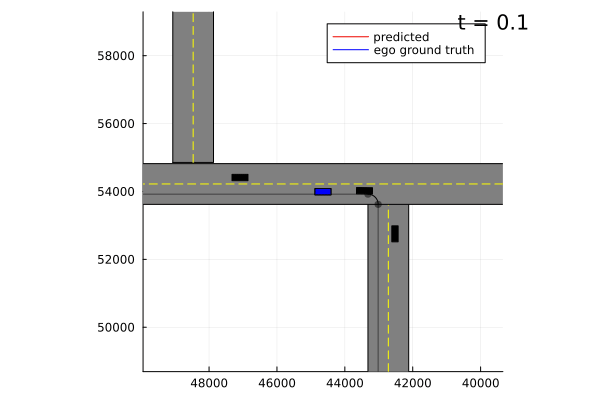

In [54]:
# visualize the results 
predicted_trajectory = zeros(game_horizon, 4)
predicted_trajectory[:, 1] = [expert_traj.x[t][1] for t in 1:game_horizon]
predicted_trajectory[:, 2] = [expert_traj.x[t][2] for t in 1:game_horizon]
predicted_trajectory[:, 3] = [expert_traj.x[t][3] for t in 1:game_horizon]
predicted_trajectory[:, 4] = [expert_traj.x[t][4] for t in 1:game_horizon]


anim = animate_trajectories([predicted_trajectory], ["red"], ["predicted"], demo[1:game_horizon, :], trajectory_plan, 1200, field_of_view = 10000, time_spacing=2)
gif(anim, "visualizations/ego_trajectory.gif", fps=15)


# anim=@animate for t in 1:game_horizon
#     plot(agent1_x, agent1_y, color="red", label="")
#     scatter!([agent1_x[t]], [agent1_y[t]], label="ego", legend=:topleft, color="red")
#     plot!(size=(400,500))
#     plot!(aspect_ratio=:equal, legend=:topleft)
#     visualize(trajectory_plan)
#     plot!(title="Trajectory Tracking \n v_ego: $ego_v_desired, v_other: $other_v_desired, comf. dist.: $ego_comfortable_distance", titlefontsize=8)

#     # set x limits and y limits to a window around the agent 
#     xlims = [agent1_x[t] - 500, agent1_x[t] + 500]
#     ylims = [agent1_y[t] - 500, agent1_y[t] + 500]
#     plot!(xlim=xlims, ylim=ylims)
# end
# save_file = string("visualizations/example_singleagent_turning.gif")
# gif(anim, save_file, fps = 5)

In [34]:
# find progress from x0
wrapper_fcn([demo[1000, 1], demo[1000, 2]])

2-element Vector{Float64}:
 27780.199999999997
    72.40000000000146

### Old little examples

In [24]:
include("../src/diff_solver.jl")
include("../src/experiment_utils.jl") # NOTICE!! Many functions are defined there.

"Forward Game Problem: generate expert demo"
# parametes: number of states, number of inputs, sampling time, horizon
nx, nu, ΔT, game_horizon = 9, 4, 0.1, 40

# setup the dynamics
struct DoubleUnicycle <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::DoubleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2], 
                                    x[8]cos(x[7]), x[8]sin(x[7]), u[3], u[4],0)
dynamics = DoubleUnicycle()
costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[1]-x[9])^2  +  2*(u[1]^2 + u[2]^2) + 20*relu( 1- (x[5]-x[1])^2 - (x[6]-x[2])^2 ) )),
        FunctionPlayerCost((g, x, u, t) -> (  8*(x[5] - x[9])^2 + 2*(u[3]^2 + u[4]^2) + 20*relu( 1- (x[5]-x[1])^2 - (x[6]-x[2])^2 ) ))   )

# indices of inputs that each player controls
player_inputs = (SVector(1,2), SVector(3,4))
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)



# get a solver, choose initial conditions and solve (in about 9 ms with AD)
x0 = SVector(
    0.5, 0., pi/2, 1,       
    1, 1, pi/2, 1,         
    0.2)
# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)


┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


(true, SystemTrajectory{40, 0.1, 9, 4, SizedVector{40, SVector{9, Float64}, Vector{SVector{9, Float64}}}, SizedVector{40, SVector{4, Float64}, Vector{SVector{4, Float64}}}}(SVector{9, Float64}[[0.5, 0.0, 1.5707963267948966, 1.0, 1.0, 1.0, 1.5707963267948966, 1.0, 0.2], [0.4973611620980389, 0.10034553422755002, 1.6233109193027642, 1.0078352194056186, 0.9930999485023164, 1.1020806916886978, 1.7047366810183568, 1.047802644056175, 0.2], [0.4899325760810583, 0.2012118042885135, 1.6652617938869723, 1.0151021128474578, 0.9731602135450084, 1.207148607796182, 1.811219734057159, 1.0920731545938351, 0.2], [0.47867765897504827, 0.3024114897026968, 1.6978165493632393, 1.0214602077374169, 0.9422919252764401, 1.3138864302456423, 1.8929322212715154, 1.130779506497138, 0.2], [0.4644720177330545, 0.40382894842563893, 1.7220863297626186, 1.0267405599525907, 0.9027333146309233, 1.4215206366339999, 1.952787978829254, 1.1630323911971088, 0.2], [0.4480987630903331, 0.5053987792200574, 1.739148788293023, 1.03

┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif")
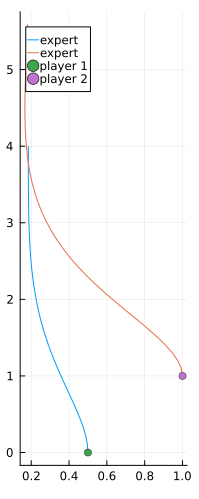

In [25]:
agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]
agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]

agent2_x = [expert_traj.x[t][5] for t in 1:game_horizon]
agent2_y = [expert_traj.x[t][6] for t in 1:game_horizon]
anim=@animate for t in 1:game_horizon
    plot(agent1_x, agent1_y, label="expert", legend=:topleft)
    plot!(agent2_x, agent2_y, label="expert", legend=:topleft)
    scatter!([agent1_x[t]], [agent1_y[t]], label="player 1", legend=:topleft)
    scatter!([agent2_x[t]], [agent2_y[t]], label="player 2", legend=:topleft)
    plot!(size=(200,500))
end
gif(anim, "expert_demo.gif", fps = 5)
# scatter(agent1_x, agent1_y, label="player 1", legend=:topleft)
# scatter!(agent2_x, agent2_y, label="player 2", legend=:topleft)
# plot!(size=(200,500))



┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif")
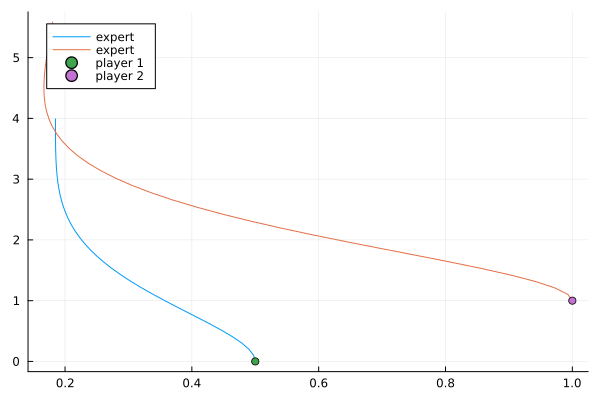

In [26]:
agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]
agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]
agent1_θ = [expert_traj.x[t][3] for t in 1:game_horizon]
agent1_v = [expert_traj.x[t][4] for t in 1:game_horizon]

agent2_x = [expert_traj.x[t][5] for t in 1:game_horizon]
agent2_y = [expert_traj.x[t][6] for t in 1:game_horizon]
agent2_v = [expert_traj.x[t][8] for t in 1:game_horizon]
agent2_θ = [expert_traj.x[t][7] for t in 1:game_horizon]
anim=@animate for t in 1:game_horizon
    plot(agent1_x, agent1_y, label="expert", legend=:topleft)
    plot!(agent2_x, agent2_y, label="expert", legend=:topleft)
    scatter!([agent1_x[t]], [agent1_y[t]], label="player 1", legend=:topleft)
    scatter!([agent2_x[t]], [agent2_y[t]], label="player 2", legend=:topleft)
    plot!(equal_aspect_ratio=true)
    # plot!(size=(200,500))
end
gif(anim, "expert_demo.gif", fps = 5)
# scatter(agent1_x, agent1_y, label="player 1", legend=:topleft)
# scatter!(agent2_x, agent2_y, label="player 2", legend=:topleft)
# plot!(size=(200,500))



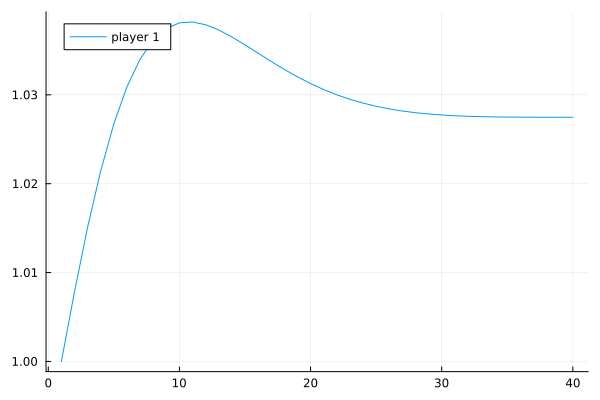

In [27]:
plot(agent1_v, label="player 1", legend=:topleft)

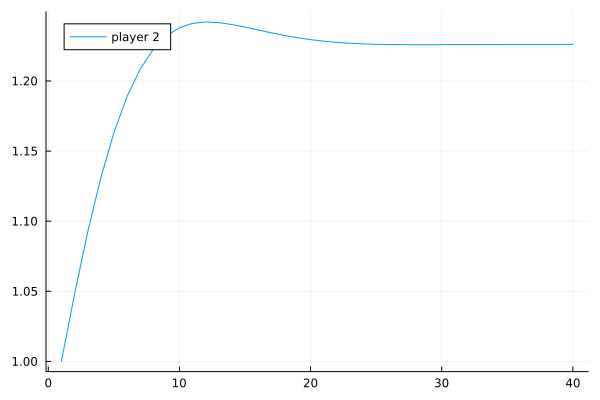

In [28]:
plot(agent2_v, label="player 2", legend=:topleft)

In [29]:
expert_traj.u

40-element SizedVector{40, SVector{4, Float64}, Vector{SVector{4, Float64}}} with indices SOneTo(40):
 [0.5251459250786743, 0.07835219405618792, 1.3394035422346036, 0.478026440561751]
 [0.41950874584208236, 0.07266893441839, 1.064830530388022, 0.44270510537660274]
 [0.32554755476267144, 0.06358094889959219, 0.8171248721435661, 0.3870635190330285]
 [0.242697803993793, 0.052803522151740445, 0.598557575577386, 0.3225288469997062]
 [0.1706245853040446, 0.0416518453758422, 0.40899718887610104, 0.2570355362716199]
 [0.10869594940767766, 0.03100211504834685, 0.24707964873631894, 0.19572184018051708]
 [0.056205464481414676, 0.021403823417920322, 0.1107849037988658, 0.141554098980237]
 [0.012368121334042068, 0.013149072119718221, -0.002105388335360672, 0.0959379563872398]
 [-0.023599139605363778, 0.006349088574762662, -0.09386112500612588, 0.05916356590864244]
 [-0.05248947899461337, 0.0009809251225172027, -0.16665882667771006, 0.030802958448328022]
 ⋮
 [-0.020163255349997498, -0.00042357129670

In [30]:
# implement the receding horizon planning:
x0 = SVector(
    0.5, 0., pi/2, 1,       
    1, 1, pi/2, 1,         
    pi)
trajectory = [x0]
T = 3
for t in 1:T
    # 1. get the current state
    x = trajectory[end]
    # 2. solve the game with the current state
    c, expert_traj, strategies = solve(g, solver, x)
    # 3. get the optimal control
    u1 = expert_traj.u[1][1:2]
    u2 = expert_traj.u[1][3:4]
    # 4. apply the control to the system
    x = dx(dynamics, x, [u1; u2], t)
    print(x)
    push!(trajectory, x)
end


[6.123233995736766e-17, 1.0, -1205.2606566173267, 38.279542742428376, 6.123233995736766e-17, 1.0, -2345.9546054054013, 167.78110901721126, 0.0][16.989807362051184, 34.302621450405105, 4.056400615169438, -2.2695904437269766e-5, -115.0627157102578, -122.1109003997011, 9.576137898660111, 0.014491308574440044, 0.0][1.3843202744196102e-5, 1.7985266637132822e-5, -12.416969278413983, 10.745817888067117, -0.014325628531833872, -0.0021850380700451978, -19.577522817441036, -6.237760140267916, 0.0]

┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif")
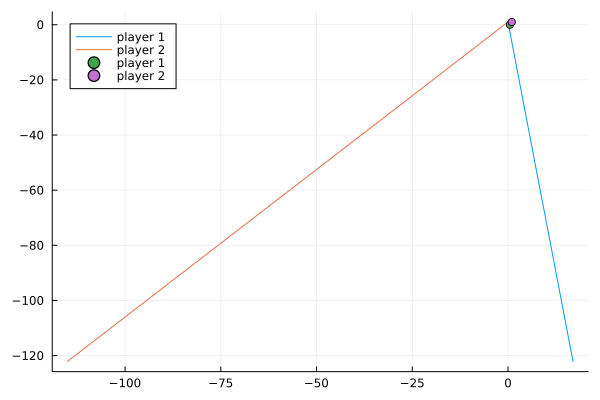

In [32]:

x1 = [trajectory[t][1] for t in 1:T]
y1 = [trajectory[t][2] for t in 1:T]
θ1 = [trajectory[t][3] for t in 1:T]
v1 = [trajectory[t][4] for t in 1:T]

x2 = [trajectory[t][5] for t in 1:T]
y2 = [trajectory[t][6] for t in 1:T]
v2 = [trajectory[t][8] for t in 1:T]
θ2 = [trajectory[t][7] for t in 1:T]

anim=@animate for t in 1:T
    plot(x1, y2, label="player 1", legend=:topleft)
    plot!(x2, y2, label="player 2", legend=:topleft)
    scatter!([x1[t]], [y1[t]], label="player 1", legend=:topleft)
    scatter!([x2[t]], [y2[t]], label="player 2", legend=:topleft)
    plot!(equal_aspect_ratio=true)
    # plot!(size=(200,500))
end
gif(anim, "expert_demo.gif", fps = 5)

In [34]:
# new cost function for arc projection:
struct Arc
    center::Vector{Float64}
    radius::Float64
    start_angle::Float64
    end_angle::Float64
end

function sampled_projection(point::Vector{Float64}, arc::Arc, num_samples::Int)
    angles = LinRange(arc.start_angle, arc.end_angle, num_samples)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    # project the point onto the arc
    distances = [norm(point - p) for p in points]
    min_distance, min_index = findmin(distances)

    return points[min_index]
end

function project(point::Vector{Float64}, arc::Arc)
    # find the angle of the point with respect to the center of the arc
    angle = atan(point[2] - arc.center[2], point[1] - arc.center[1])

    # check if the angle is within the arc accounting for the 2pi rollover
    # first make sure start_angle < end_angle and angle > start_angle 
    start_angle = arc.start_angle % (2 * pi)
    end_angle = arc.end_angle % (2 * pi)
    if end_angle < start_angle
        end_angle += 2 * pi
    end

    if angle < start_angle
        angle += 2 * pi
    end

    # now, check if the angle is within the arc. if it is, then the projected point 
    # is in the interior of the arc. otherwise, it's one of the edge points. 
    if start_angle <= angle <= end_angle
        projected_point = arc.center .+ arc.radius * [cos(angle), sin(angle)]
    else
        start_vertex = arc.center .+ arc.radius * [cos(start_angle), sin(start_angle)]
        end_vertex = arc.center .+ arc.radius * [cos(end_angle), sin(end_angle)]
        distance_start_vertex = norm(point - start_vertex)
        distance_end_vertex = norm(point - end_vertex)
        if distance_start_vertex < distance_end_vertex
            projected_point = start_vertex
        else
            projected_point = end_vertex
        end
    end 

    return projected_point
end 

function project_and_distance(point, set)
    projected_point = project(point, set)
    distance = norm(point - projected_point)
    return projected_point, distance
end 

function plot_arc(arc::Arc)
    angles = LinRange(arc.start_angle, arc.end_angle, 100)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    plot!([p[1] for p in points], [p[2] for p in points])
end


ErrorException: invalid redefinition of constant Arc

In [35]:
arc = Arc([0.0, 0.0], 1.0, 0, pi/2)
point = [2 * rand() - 1, 2 * rand() - 1]
projected_point = project(point, arc)
plot(equal_aspect_ratio=true)
plot_arc(arc)
scatter!([point[1]], [point[2]], label="point")
scatter!([projected_point[1]], [projected_point[2]], label="projected point")



UndefVarError: UndefVarError: `plot_arc` not defined